#  Visualisation du Dataset M5 Forecasting – Walmart



In [1]:
# ── Imports ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


In [2]:


sales_path  = r"C:\Users\ayady\OneDrive\Desktop\pfe\data\raw_data\sales_train_evaluation.csv"
cal_path    = r"C:\Users\ayady\OneDrive\Desktop\pfe\data\raw_data\calendar.csv"
prices_path = r"C:\Users\ayady\OneDrive\Desktop\pfe\data\raw_data\sell_prices.csv"

# Chargement
sales   = pd.read_csv(sales_path)
cal     = pd.read_csv(cal_path)
prices  = pd.read_csv(prices_path)

print(f'sales   : {sales.shape[0]:,} lignes × {sales.shape[1]} colonnes')
print(f'calendar: {cal.shape[0]:,} lignes × {cal.shape[1]} colonnes')
print(f'prices  : {prices.shape[0]:,} lignes × {prices.shape[1]} colonnes')

sales   : 30,490 lignes × 1947 colonnes
calendar: 1,969 lignes × 14 colonnes
prices  : 6,841,121 lignes × 4 colonnes


---
## 1️ Aperçu des fichiers

In [3]:
print('=== sales_train_validation (5 premières lignes) ===')
display(sales.head())


=== sales_train_validation (5 premières lignes) ===


,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0


In [4]:
print('=== calendar (5 premières lignes) ===')
display(cal.head())


=== calendar (5 premières lignes) ===


,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [5]:
print('=== sell_prices (5 premières lignes) ===')
display(prices.head())

=== sell_prices (5 premières lignes) ===


,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [6]:
n_items    = sales['item_id'].nunique()
n_stores   = sales['store_id'].nunique()
n_states   = sales['state_id'].nunique()
n_cats     = sales['cat_id'].nunique()
n_days     = len([c for c in sales.columns if c.startswith('d_')])

print('━'*45)
print(f'  Produits uniques (item_id)  : {n_items:>6,}')
print(f'  Magasins (store_id)         : {n_stores:>6}')
print(f'  États (state_id)            : {n_states:>6}')
print(f'  Catégories (cat_id)         : {n_cats:>6}')
print(f'  Jours de ventes             : {n_days:>6,}')
print(f'  Séries temporelles totales  : {len(sales):>6,}')
print('━'*45)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Produits uniques (item_id)  :  3,049
  Magasins (store_id)         :     10
  États (state_id)            :      3
  Catégories (cat_id)         :      3
  Jours de ventes             :  1,941
  Séries temporelles totales  : 30,490
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


---
##  Répartition des produits par catégorie et département

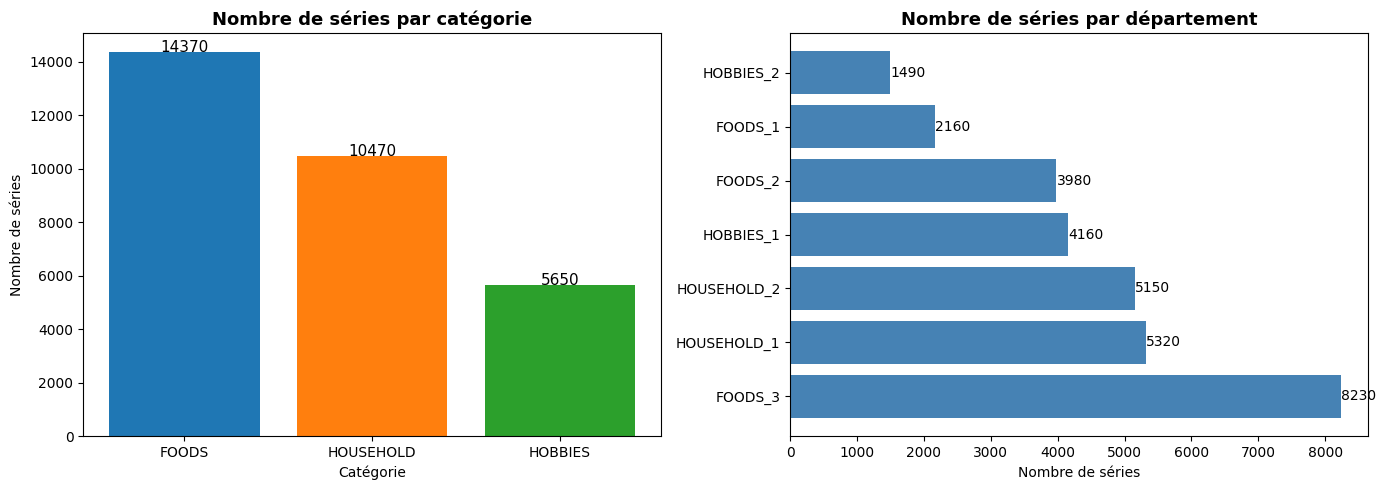

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Catégories
cat_counts = sales['cat_id'].value_counts()
axes[0].bar(cat_counts.index, cat_counts.values, color=['#1f77b4','#ff7f0e','#2ca02c'])
axes[0].set_title('Nombre de séries par catégorie', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Catégorie')
axes[0].set_ylabel('Nombre de séries')
for i, v in enumerate(cat_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontsize=11)

# Départements
dept_counts = sales['dept_id'].value_counts()
axes[1].barh(dept_counts.index, dept_counts.values, color='steelblue')
axes[1].set_title('Nombre de séries par département', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Nombre de séries')
for i, v in enumerate(dept_counts.values):
    axes[1].text(v + 5, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.show()

---
##  Distribution des prix de vente

---
## 9️ Exemple : courbe de ventes d'un produit spécifique

In [8]:
# Changer item_example et store_example selon ce que tu veux montrer
item_example  = 'FOODS_3_090'
store_example = 'CA_1'

row = sales[(sales['item_id'] == item_example) & (sales['store_id'] == store_example)]

if len(row) == 0:
    # Fallback : prend le premier produit disponible
    row = sales.iloc[[0]]
    item_example  = row['item_id'].values[0]
    store_example = row['store_id'].values[0]
    print(f'Produit non trouvé – affichage de {item_example} / {store_example}')

ts = row[day_cols].values.flatten()
ts_df = pd.DataFrame({'d': day_cols, 'sales': ts}).join(cal_sub, on='d').dropna().sort_values('date')

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(ts_df['date'], ts_df['sales'], linewidth=1, color='steelblue')
ax.fill_between(ts_df['date'], ts_df['sales'], alpha=0.2, color='steelblue')
ax.set_title(f'Ventes journalières – {item_example}  /  {store_example}', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Unités vendues')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

NameError: name 'day_cols' is not defined